# Fine tune BCS Cow Classification

## Re-Training 

In [ ]:
from ultralytics import settings
from ultralytics import YOLO
from pathlib import Path
import os
import shutil
import glob
import pandas as pd

settings.update({'mlflow': False})

# Clear cache sebelum training
cache_dir = PROCESSED_DIR / '.cache'
if cache_dir.exists():
    shutil.rmtree(cache_dir)

# Log ke MLflow (training utama)
run_id = log_training_metadata(
    model_type="YOLOv8-CLS",
    model_name=config['model_yolo']['model_name'],
    pretrained=config['model_yolo']['pretrained'],
    batch_size=config['training']['batch_size'],
    num_epochs=config['training']['num_epochs'],
    learning_rate=config['training']['learning_rate']
)

# Load model base (misal: yolov8n-cls.pt)
model_name = config['model_yolo']['pretrained']
model = YOLO(model_name)

print(f"🚀 Starting training with dataset: {PROCESSED_DIR}")
print(f"📊 Experiment name: yolov8_{run_id[:8]}")

# Debugging flags (opsional)
os.environ['TORCH_USE_CUDA_DSA'] = '1'

try:
    results = model.train(
        data=str(PROCESSED_DIR),
        epochs=config['training']['num_epochs'],
        imgsz=config['model_yolo']['input_size'],
        batch=config['training']['batch_size'],
        device=config['training']['yolo_device'],
        project=str(MODELS_DIR),
        name=f"yolov8_{run_id[:8]}",
        exist_ok=True,
        patience=config['training']['early_stopping_patience'],
        workers=config['training']['workers'],
        seed=config['data']['random_seed'],
        deterministic=True,
        plots=True
    )
    print("✅ Training selesai!")
    
except RuntimeError as e:
    print(f"❌ CUDA Error detected: {e}")
    print("\n🔧 TROUBLESHOOTING:")
    print("1. Coba turunkan batch_size, misalnya = 2")
    print("2. Coba device='cpu' satu epoch untuk cek data")
    print("3. Pastikan semua gambar valid")
    print("4. Pastikan nama folder kelas tepat: ['3.25', '3.5', '3.75', '4.0', '4.25']")
    raise

# Ambil ringkasan hasil training utama
train_loss = float(results.results_dict.get("train/loss", 0))
train_accuracy = float(results.results_dict.get("metrics/accuracy_top1", 0))
epochs_trained = results.epochs if hasattr(results, 'epochs') else config['training']['num_epochs']

runs_dir = Path(MODELS_DIR) / 'yolov8*'
all_runs = sorted(glob.glob(str(runs_dir)), key=os.path.getmtime, reverse=True)
latest_run_dir = Path(all_runs[0])
results_csv_path = latest_run_dir / 'results.csv'

df = pd.read_csv(results_csv_path)
df.columns = df.columns.str.strip()

last_epoch = df.iloc[-1]

acc_top1 = last_epoch.get('metrics/accuracy_top1', 0.0)
train_loss = last_epoch.get('train/loss', 0.0)
val_loss = last_epoch.get('val/loss', 0.0)

print(f"\n✅ Training completed!")
print(f"📂 Results found at: {latest_run_dir}")
print(f"📈 Final Accuracy: {acc_top1:.4f}")
print(f"📉 Final Train Loss: {train_loss:.4f}")
print(f"📉 Final Val Loss: {val_loss:.4f}")

## Fine-Tuning Old Model

Define Config

In [8]:
from ultralytics import settings
from ultralytics import YOLO
from pathlib import Path
import os
import shutil
import glob
import pandas as pd

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
model_type = "YOLOv8-CLS-FINETUNE"
model_name = "yolov8n-cls"
batch_size = 128
input_size = 224
device = 0
early_stopping_patience = 10
workers = 2
random_seed = 42

# Hyperparameter fine-tuning
epochs = 20
learning_rate = 0.0001

Training

In [9]:
print("\n====================")
print("🔁 FINE-TUNING MODEL")
print("====================")

# Path model yang akan di fine-tune
best_ckpt = Path("../models/production/20251125_202253/best.pt")

if not best_ckpt.exists():
    raise FileNotFoundError(f"❌ best.pt tidak ditemukan di: {best_ckpt}")

print(f"✅ Akan fine-tune dari: {best_ckpt}")
print(f"🔧 Fine-tune epochs : {epochs}")
print(f"🔧 Fine-tune LR     : {learning_rate}")

# Log ke MLflow (fine-tuning)
try:
    run_id_ft = log_training_metadata(
        model_type=str(model_type),
        model_name=str(model_name),
        pretrained=str(best_ckpt),
        batch_size=batch_size,
        num_epochs=epochs,
        learning_rate=learning_rate
    )
except NameError:
    run_id_ft = "finetune"
    print("ℹ️ log_training_metadata tidak ditemukan, lanjut tanpa MLflow logging untuk fine-tuning.")

experiment_name_ft = f"yolov8_finetune_{str(run_id_ft)[:8]}"

# Load model dari best.pt
model_ft = YOLO(str(best_ckpt))

print(f"🚀 Mulai fine-tuning dengan dataset: {PROCESSED_DIR}")
print(f"📊 Fine-tune experiment name: {experiment_name_ft}")

try:
    results_ft = model_ft.train(
        data=str(PROCESSED_DIR),
        epochs=epochs,
        imgsz=input_size,
        batch=batch_size,
        device=device,
        project=str(MODELS_DIR),
        name=experiment_name_ft,
        exist_ok=True,
        patience=early_stopping_patience,
        workers=workers,
        seed=random_seed,
        deterministic=True,
        plots=True,
        optimizer='SGD',
        lr0=learning_rate,
        momentum=0.937,
        cos_lr=True,
        warmup_epochs=0.0
    )
    print("✅ Fine-tuning selesai!")
except RuntimeError as e:
    print(f"❌ CUDA Error detected saat fine-tuning: {e}")
    print("\n🔧 TROUBLESHOOTING:")
    print("1. Turunkan batch_size, misalnya = 2")
    print("2. Coba device='cpu' untuk cek masalah data")
    print("3. Cek kembali struktur folder klasifikasi train/val/test dan nama kelas")
    raise

# Ringkasan hasil fine-tuning
ft_run_dir = MODELS_DIR / experiment_name_ft
ft_results_csv = ft_run_dir / 'results.csv'

if ft_results_csv.exists():
    df_ft = pd.read_csv(ft_results_csv)
    df_ft.columns = df_ft.columns.str.strip()
    last_epoch_ft = df_ft.iloc[-1]

    print("\n📈 Akurasi per-epoch (5 epoch terakhir):")
    print(df_ft[['epoch', 'metrics/accuracy_top1']].tail())

    acc_top1_ft = last_epoch_ft.get('metrics/accuracy_top1', 0.0)
    train_loss_ft = last_epoch_ft.get('train/loss', 0.0)
    val_loss_ft = last_epoch_ft.get('val/loss', 0.0)

    print(f"\n📂 Fine-tune results dir : {ft_run_dir}")
    print(f"🎯 Fine-tune Top-1 Acc   : {acc_top1_ft * 100:.2f}%")
    print(f"📉 Fine-tune Train Loss  : {train_loss_ft:.4f}")
    print(f"📉 Fine-tune Val Loss    : {val_loss_ft:.4f}")
else:
    print(f"\n⚠️ results.csv untuk fine-tuning tidak ditemukan di: {ft_results_csv}")


🔁 FINE-TUNING MODEL
✅ Akan fine-tune dari: ..\models\production\20251125_202253\best.pt
🔧 Fine-tune epochs : 20
🔧 Fine-tune LR     : 0.0001
ℹ️ log_training_metadata tidak ditemukan, lanjut tanpa MLflow logging untuk fine-tuning.
🚀 Mulai fine-tuning dengan dataset: ..\data\processed
📊 Fine-tune experiment name: yolov8_finetune_finetune
New https://pypi.org/project/ultralytics/8.3.235 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.230  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=..\data\processed, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipu

## Evaluasi Model Terbaru

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import confusion_matrix
import time
import mlflow

ft_run_dir = MODELS_DIR / experiment_name_ft
best_weight_path = ft_run_dir / 'weights' / 'best.pt'

if not best_weight_path.exists():
    raise FileNotFoundError(f"❌ best.pt hasil fine-tuning tidak ditemukan di: {best_weight_path}")

print(f"\n[1] Loading best fine-tuned model from: {best_weight_path}")
best_model = YOLO(str(best_weight_path))


[1] Loading best fine-tuned model from: ..\models\yolov8_finetune_finetune\weights\best.pt


Evaluasi di TEST SET (Top-1, Top-5, latency)

In [13]:
print("\n[2] Evaluasi di TEST SET (YOLO .val split='test')")

test_results = best_model.val(
    data=str(PROCESSED_DIR),
    split='test',
    batch=32,
    imgsz=input_size,
    device=device,
    verbose=True,
    plots=False,
    save_json=False,
    save=False
)

top1 = float(test_results.top1)
top5 = float(test_results.top5)

print("\n" + "="*70)
print("📊 TEST SET EVALUATION RESULTS (YOLO)")
print("="*70)
print(f"\n🎯 Accuracy Metrics:")
print(f"   Top-1 Accuracy: {top1 * 100:.2f}%")
print(f"   Top-5 Accuracy: {top5 * 100:.2f}%")

# Speed (ms per image)
pre_ms = float(test_results.speed['preprocess'])
inf_ms = float(test_results.speed['inference'])
post_ms = float(test_results.speed.get('postprocess', 0.0))
mean_latency = pre_ms + inf_ms + post_ms

print(f"\n⚡ Performance:")
print(f"   Preprocess: {pre_ms:.2f} ms")
print(f"   Inference:  {inf_ms:.2f} ms")
print(f"   Postprocess:{post_ms:.2f} ms")
print(f"   Total:      {mean_latency:.2f} ms per image")


[2] Evaluasi di TEST SET (YOLO .val split='test')
Ultralytics 8.3.230  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,441,285 parameters, 0 gradients, 3.3 GFLOPs
train: E:\Folder Kuliah\Semester 7\CAPSTONE PROJECT\Repository\bcs-cow-project\ml\data\processed\train... found 37496 images in 5 classes  
val: E:\Folder Kuliah\Semester 7\CAPSTONE PROJECT\Repository\bcs-cow-project\ml\data\processed\val... found 8035 images in 5 classes  
test: E:\Folder Kuliah\Semester 7\CAPSTONE PROJECT\Repository\bcs-cow-project\ml\data\processed\test... found 8035 images in 5 classes  
test: Fast image access  (ping: 3.05.2 ms, read: 3.70.4 MB/s, size: 42.7 KB)
test: Scanning E:\Folder Kuliah\Semester 7\CAPSTONE PROJECT\Repository\bcs-cow-project\ml\data\processed\test... 8035 images, 0 corrupt: 100% ━━━━━━━━━━━━ 8035/8035 19.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 252/252 7.5it/s 33.5

Training Curves (Loss & Accuracy) - Fine-tune run


[3] Training Curves (Loss & Accuracy) dari fine-tune run
Columns detected:
['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


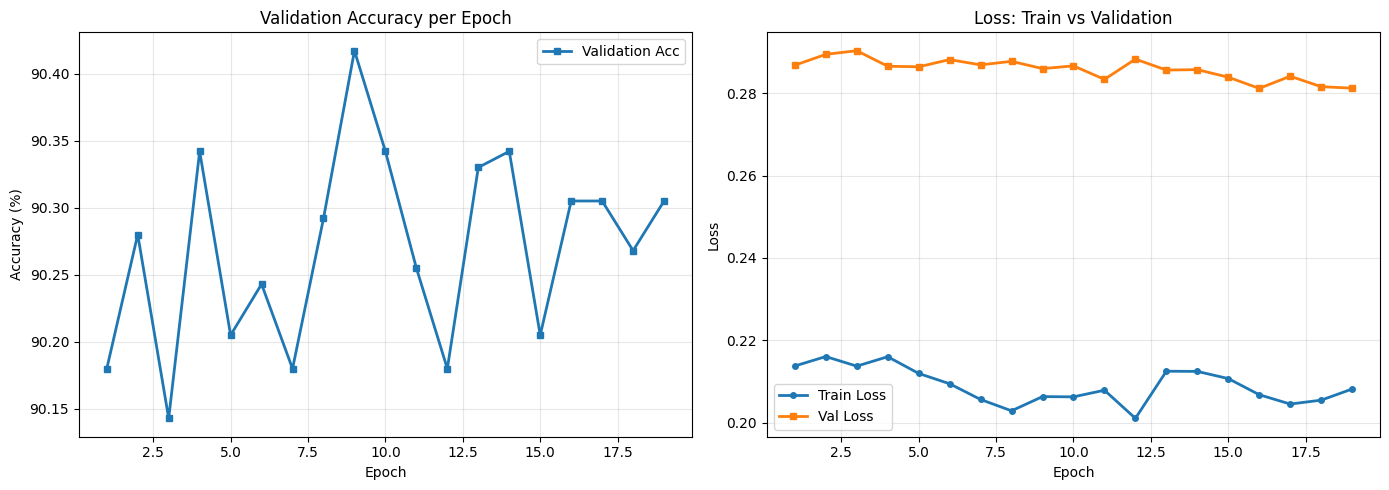

TRAINING CURVES - ANALYSIS (FINE-TUNE)

[PLOT 1] Loss Analysis
- Train Loss: 0.2138 → 0.2082
- Val Loss:   0.2868 → 0.2812

[PLOT 2] Metric Analysis
- Val Score:  90.18% → 90.31%

Training Statistics:
  Final Train Loss:  0.2082
  Final Val Loss:    0.2812
  Train-Val Gap:     0.0731 (✅ Good Fit / No Overfitting)


In [16]:
print("\n[3] Training Curves (Loss & Accuracy) dari fine-tune run")

results_path = ft_run_dir / "results.csv"

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return df[c].values
    return None

if results_path.exists():
    results_df = pd.read_csv(results_path)
    results_df.columns = [c.strip() for c in results_df.columns]

    print("Columns detected:")
    print(results_df.columns.tolist())

    # Ambil kolom-kolom penting
    epochs        = pick_col(results_df, ['epoch'])
    train_loss_arr = pick_col(results_df, ['train/loss', 'train_loss', 'loss/train'])
    val_loss_arr   = pick_col(results_df, ['val/loss', 'val_loss', 'loss/val'])
    val_acc_arr    = pick_col(results_df, [
        'metrics/accuracy_top1', 'accuracy/top1', 'metrics/acc_top1',
        'val/accuracy', 'val_acc'
    ])

    # Cek ada yang gagal terbaca tidak
    if any(x is None for x in [epochs, train_loss_arr, val_loss_arr, val_acc_arr]):
        print("⚠️ Tidak bisa menemukan salah satu kolom metrik. Plot & analisis tidak bisa dibuat.")
    else:
        # ---------------- PLOTTING ----------------
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Plot Accuracy
        axes[0].plot(epochs, val_acc_arr * 100, 's-', label='Validation Acc', linewidth=2, markersize=4)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].set_title('Validation Accuracy per Epoch')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Plot Loss
        axes[1].plot(epochs, train_loss_arr, 'o-', label='Train Loss', linewidth=2, markersize=4)
        axes[1].plot(epochs, val_loss_arr, 's-', label='Val Loss', linewidth=2, markersize=4)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Loss: Train vs Validation')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # ---------------- ANALISIS OVERFITTING SEDERHANA ----------------
        if len(epochs) > 0:
            t_start, t_end = float(train_loss_arr[0]), float(train_loss_arr[-1])
            v_start, v_end = float(val_loss_arr[0]),   float(val_loss_arr[-1])
            acc_start, acc_end = float(val_acc_arr[0]), float(val_acc_arr[-1])

            gap = v_end - t_end  # selisih val vs train loss di epoch terakhir

            if gap > 0.5:
                status = "🚨 High Overfitting (Gap besar)"
            elif gap > 0.15:
                status = "⚠️ Moderate Overfitting"
            elif gap < 0:
                status = "❓ Underfitting / Data Leakage (Val < Train)"
            else:
                status = "✅ Good Fit / No Overfitting"

            print("="*30)
            print("TRAINING CURVES - ANALYSIS (FINE-TUNE)")
            print("="*30)

            print(f"\n[PLOT 1] Loss Analysis")
            print(f"- Train Loss: {t_start:.4f} → {t_end:.4f}")
            print(f"- Val Loss:   {v_start:.4f} → {v_end:.4f}")

            print(f"\n[PLOT 2] Metric Analysis")
            print(f"- Val Score:  {acc_start*100:.2f}% → {acc_end*100:.2f}%")

            print("\nTraining Statistics:")
            print(f"  Final Train Loss:  {t_end:.4f}")
            print(f"  Final Val Loss:    {v_end:.4f}")
            print(f"  Train-Val Gap:     {gap:.4f} ({status})")

else:
    print(f"⚠️ results.csv untuk fine-tuning tidak ditemukan di: {results_path}")

Confusion Matrix di TEST SET


[4] Confusion Matrix - TEST SET
Classes (urut index): ['3.25', '3.5', '3.75', '4.0', '4.25']

Overall Accuracy (Confusion Matrix): 90.12%
Per-class Accuracy:
  3.25: 90.54% (1024/1131)
  3.5: 89.84% (1786/1988)
  3.75: 89.01% (1903/2138)
  4.0: 90.45% (1704/1884)
  4.25: 92.17% (824/894)


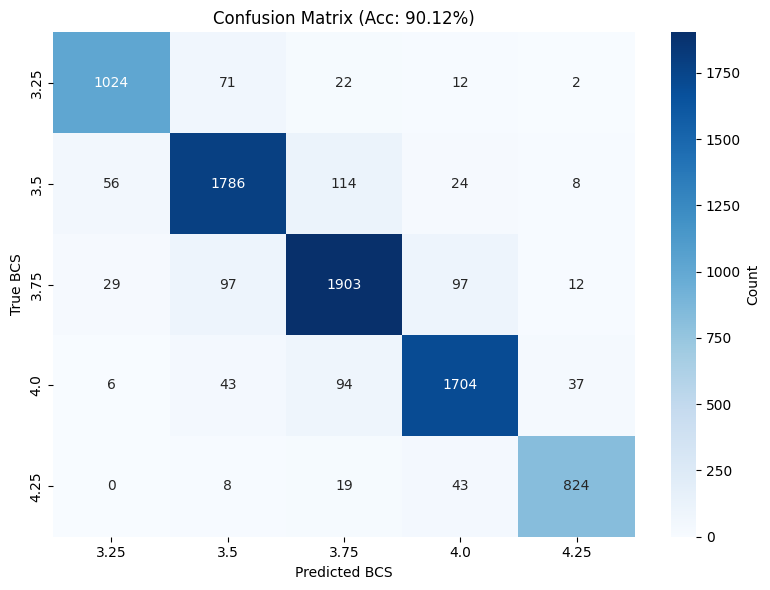

In [17]:
print("\n[4] Confusion Matrix - TEST SET")

test_dir = PROCESSED_DIR / 'test'
classes = sorted([d.name for d in test_dir.iterdir() if d.is_dir()])
print(f"Classes (urut index): {classes}")

true_labels = []
pred_labels = []

for class_idx, class_name in enumerate(classes):
    class_dir = test_dir / class_name
    for img_file in class_dir.glob('*.jpg'):
        results = best_model(str(img_file), verbose=False)[0]
        true_labels.append(class_idx)
        pred_labels.append(results.probs.top1)

true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)

cm = confusion_matrix(true_labels, pred_labels)

# Overall Accuracy dari confusion matrix
overall_acc = np.trace(cm) / np.sum(cm)

print(f"\nOverall Accuracy (Confusion Matrix): {overall_acc:.2%}")
print("Per-class Accuracy:")

row_sums = cm.sum(axis=1)
for i, class_name in enumerate(classes):
    correct = cm[i, i]
    total = row_sums[i]
    acc = correct / total if total > 0 else 0
    print(f"  {class_name}: {acc:.2%} ({correct}/{total})")

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=classes, yticklabels=classes,
    cmap='Blues', cbar_kws={'label': 'Count'}
)
plt.xlabel('Predicted BCS')
plt.ylabel('True BCS')
plt.title(f'Confusion Matrix (Acc: {overall_acc:.2%})')
plt.tight_layout()
plt.show()

Error Distribution & Key Metrics (BCS regression view)


[5] ERROR DISTRIBUTION & KEY METRICS - TEST SET

Performance Summary:
  Exact Match:          90.12%
  Accuracy (±0.25):     97.70%
  Accuracy (±0.50):     99.55%

Error Metrics:
  Mean Absolute Error:  0.0316 BCS
  RMSE:                 0.1096 BCS
  Error Std Dev:        0.1096

Prediction Bias Analysis:
  Max Over-prediction: +1.00 BCS
  Max Under-prediction: -0.75 BCS
  Model Bias:           -0.0003 (TEND TO UNDER-PREDICT (-))


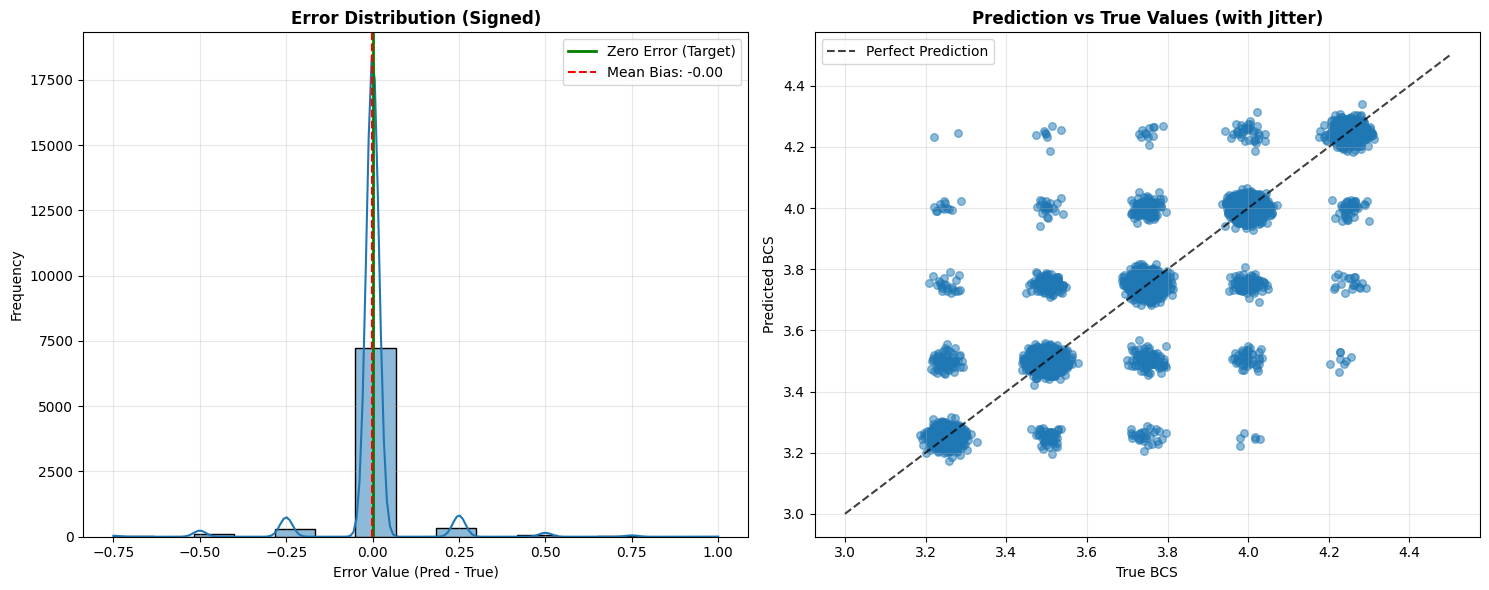

In [18]:
print("\n[5] ERROR DISTRIBUTION & KEY METRICS - TEST SET")
print("===============================================")

y_true = true_labels
y_pred = pred_labels

# Asumsi index 0 → BCS 3.25, lalu naik 0.25
signed_errors = (y_pred - y_true) * 0.25
abs_errors = np.abs(signed_errors)

mae = float(np.mean(abs_errors))
rmse = float(np.sqrt(np.mean(signed_errors**2)))
std_error = float(np.std(signed_errors))

acc_025 = float(np.mean(abs_errors <= 0.25) * 100)
acc_050 = float(np.mean(abs_errors <= 0.50) * 100)
acc_exact = float(np.mean(abs_errors == 0.0) * 100)

print("\nPerformance Summary:")
print(f"  Exact Match:          {acc_exact:.2f}%")
print(f"  Accuracy (±0.25):     {acc_025:.2f}%")
print(f"  Accuracy (±0.50):     {acc_050:.2f}%")

print("\nError Metrics:")
print(f"  Mean Absolute Error:  {mae:.4f} BCS")
print(f"  RMSE:                 {rmse:.4f} BCS")
print(f"  Error Std Dev:        {std_error:.4f}")

print("\nPrediction Bias Analysis:")
print(f"  Max Over-prediction: +{np.max(signed_errors):.2f} BCS")
print(f"  Max Under-prediction: {np.min(signed_errors):.2f} BCS")
mean_bias = float(np.mean(signed_errors))
bias_status = "TEND TO OVER-PREDICT (+)" if mean_bias > 0 else "TEND TO UNDER-PREDICT (-)"
print(f"  Model Bias:           {mean_bias:.4f} ({bias_status})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Histogram error
sns.histplot(signed_errors, bins=15, kde=True, ax=ax1, edgecolor='black')
ax1.axvline(0, color='green', linestyle='-', linewidth=2, label='Zero Error (Target)')
ax1.axvline(mean_bias, color='red', linestyle='--', label=f'Mean Bias: {mean_bias:.2f}')
ax1.set_title('Error Distribution (Signed)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Error Value (Pred - True)', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scatter True vs Predicted (jitter)
jitter_true = y_true * 0.25 + 3.25 + np.random.normal(0, 0.02, size=len(y_true))
jitter_pred = y_pred * 0.25 + 3.25 + np.random.normal(0, 0.02, size=len(y_pred))

ax2.scatter(jitter_true, jitter_pred, alpha=0.5, s=30)
lims = [3.0, 4.5]
ax2.plot(lims, lims, 'k--', alpha=0.75, label='Perfect Prediction')
ax2.set_title('Prediction vs True Values (with Jitter)', fontsize=12, fontweight='bold')
ax2.set_xlabel('True BCS', fontsize=10)
ax2.set_ylabel('Predicted BCS', fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sample Prediction Visualization


[6] Sample Predictions (Test Images)


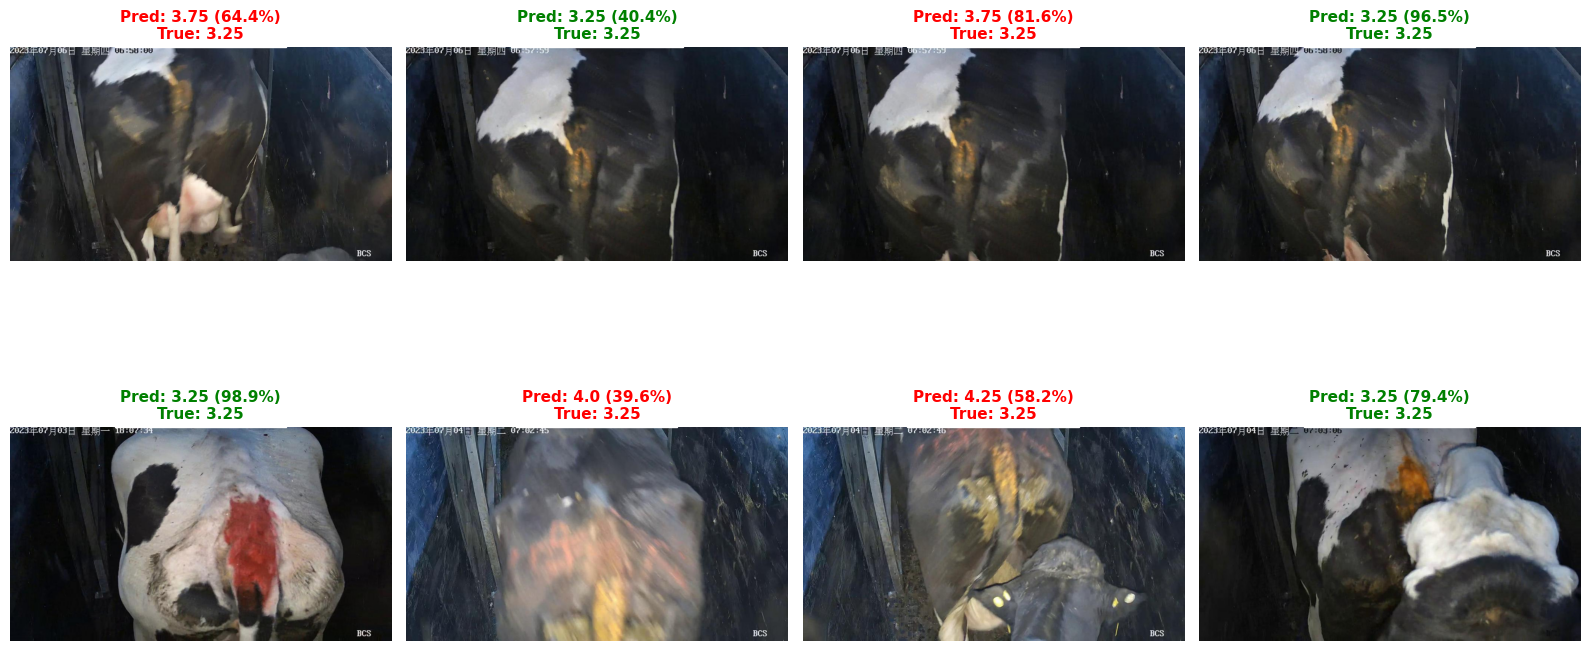

In [19]:
print("\n[6] Sample Predictions (Test Images)")

test_images = glob.glob(str(test_dir / '*' / '*.jpg'))[:8]

if test_images:
    fig, axes = plt.subplots(2, 4, figsize=(16, 9))
    axes = axes.flatten()

    for i, img_path in enumerate(test_images):
        if i >= len(axes):
            break

        results = best_model(img_path, verbose=False)[0]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        top1_idx = results.probs.top1
        conf = results.probs.top1conf.item()
        pred_label = results.names[top1_idx]
        true_label = Path(img_path).parent.name

        axes[i].imshow(img)
        color = 'green' if pred_label == true_label else 'red'
        title_text = f"Pred: {pred_label} ({conf:.1%})\nTrue: {true_label}"
        axes[i].set_title(title_text, fontsize=11, fontweight='bold', color=color, backgroundcolor='white')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Inference Time Measurement (Simulation)


[8] INFERENCE TIME MEASUREMENT (REAL TEST IMAGES)

Measured on 200 real test images:

Inference Time Statistics (ms):
  Average:   13.43
  Min:       12.05
  Max:       27.79
  Std Dev:   1.74
  P95:       15.56

Preprocessing Time (from YOLO .val):
  Average:   0.07 ms

Total Time per Image: 13.50 ms
Throughput: 74.09 images/sec

✅ Status: PASSED (Target > 20 img/sec)


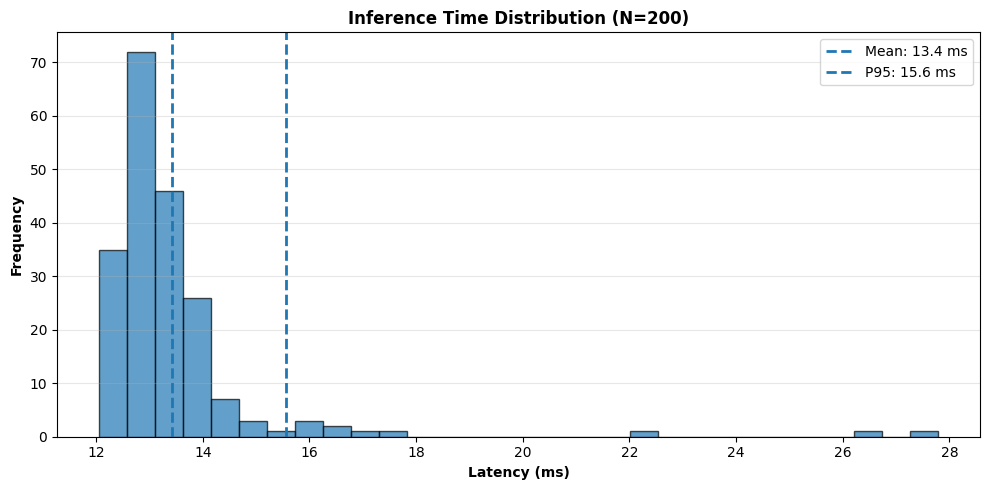

In [20]:
print("\n[8] INFERENCE TIME MEASUREMENT (REAL TEST IMAGES)")
print("=================================================")

# pakai semua gambar test atau subset (misal 200) biar cepat
all_test_images = glob.glob(str(test_dir / '*' / '*.jpg'))
num_samples = min(200, len(all_test_images))

if num_samples == 0:
    print("⚠️ Tidak ada gambar di test_dir, skip inference time measurement.")
else:
    times = []

    for img_path in all_test_images[:num_samples]:
        t0 = time.perf_counter()
        _ = best_model(img_path, verbose=False)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000.0)  # ke ms

    times = np.array(times)

    avg_inf = float(times.mean())
    min_inf = float(times.min())
    max_inf = float(times.max())
    std_inf = float(times.std())
    p95_inf = float(np.percentile(times, 95))

    # Preprocess time dari YOLO .val sebelumnya (approx)
    avg_pre = pre_ms

    total_time_per_img = avg_pre + avg_inf
    throughput = 1000.0 / total_time_per_img  # img/sec

    target_throughput = 20  # contoh target
    is_pass = throughput > target_throughput
    status_icon = "✅" if is_pass else "❌"
    status_text = "PASSED" if is_pass else "FAILED"

    print(f"\nMeasured on {num_samples} real test images:")
    print("\nInference Time Statistics (ms):")
    print(f"  Average:   {avg_inf:.2f}")
    print(f"  Min:       {min_inf:.2f}")
    print(f"  Max:       {max_inf:.2f}")
    print(f"  Std Dev:   {std_inf:.2f}")
    print(f"  P95:       {p95_inf:.2f}")

    print("\nPreprocessing Time (from YOLO .val):")
    print(f"  Average:   {avg_pre:.2f} ms")

    print(f"\nTotal Time per Image: {total_time_per_img:.2f} ms")
    print(f"Throughput: {throughput:.2f} images/sec")

    print(f"\n{status_icon} Status: {status_text} (Target > {target_throughput} img/sec)")

    # Plot distribusi latency
    plt.figure(figsize=(10, 5))
    plt.hist(times, bins=30, alpha=0.7, edgecolor='black')
    plt.axvline(avg_inf, linestyle='--', linewidth=2, label=f'Mean: {avg_inf:.1f} ms')
    plt.axvline(p95_inf, linestyle='--', linewidth=2, label=f'P95: {p95_inf:.1f} ms')

    plt.xlabel('Latency (ms)', fontweight='bold')
    plt.ylabel('Frequency', fontweight='bold')
    plt.title(f'Inference Time Distribution (N={num_samples})', fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

Summary: Model Performance Metrics

In [28]:
print("\n" + "="*70)
print("SUMMARY: MODEL PERFORMANCE METRICS (PHASE 2)")
print("="*70)

# Target fase 2 
TARGET_TOP1 = 0.90
TARGET_MAE = 0.032
TARGET_ACC_025 = 97.0
TARGET_LATENCY = 0.70   

metrics_summary = {
    'Metric |': [
        'Top-1 Accuracy |',
        'MAE (BCS) |',
        'Accuracy@±0.25 |',
        'Mean Latency (ms) |'
    ],
    'Value |': [
        f'{overall_acc:.2%} |',
        f'{mae:.4f} |',
        f'{acc_025:.2f}% |',
        f'{mean_latency:.2f} |'
    ],
    'Phase 2 Target |': [
        f'≥ {int(TARGET_TOP1*100)}% |',
        f'< {TARGET_MAE:.4f} |',
        f'≥ {TARGET_ACC_025:.0f}% |',
        f'< {TARGET_LATENCY:.2f} ms |'
    ],
    'Status': [
        'PASS' if overall_acc >= TARGET_TOP1 else 'FAIL',
        'PASS' if mae < TARGET_MAE else 'FAIL',
        'PASS' if acc_025 >= TARGET_ACC_025 else 'FAIL',
        'PASS' if mean_latency < TARGET_LATENCY else 'FAIL'
    ]
}

df_metrics = pd.DataFrame(metrics_summary)
print(df_metrics.to_string(index=False))
print("="*70)

passed = sum(1 for s in metrics_summary['Status'] if 'PASS' in s)
total = len(metrics_summary['Status'])
print(f"\n🎯 Overall: {passed}/{total} metrics PASSED Phase 2 targets")
if passed == total:
    print("✅ Model ready for next step (Production / Phase 3)")
else:
    print("⚠️ Some metrics below Phase 2 targets - further optimization needed")


SUMMARY: MODEL PERFORMANCE METRICS (PHASE 2)
           Metric |  Value | Phase 2 Target | Status
   Top-1 Accuracy | 90.12% |          ≥ 90% |   PASS
        MAE (BCS) | 0.0316 |       < 0.0320 |   PASS
   Accuracy@±0.25 | 97.70% |          ≥ 97% |   PASS
Mean Latency (ms) |   0.52 |      < 0.70 ms |   PASS

🎯 Overall: 4/4 metrics PASSED Phase 2 targets
✅ Model ready for next step (Production / Phase 3)


Log ke MLflow untuk run fine-tuning

In [29]:
print("\n[7] Logging metrics ke MLflow (jika ada active_run)")

if mlflow.active_run():
    mlflow.log_metric("test_top1_acc", top1)
    mlflow.log_metric("test_top5_acc", top5)
    mlflow.log_metric("test_overall_acc_confmat", overall_acc)
    mlflow.log_metric("test_mae_bcs", mae)
    mlflow.log_metric("test_acc_pm_0_25", acc_025)
    mlflow.log_metric("test_acc_pm_0_50", acc_050)
    mlflow.log_metric("test_mean_latency_ms", mean_latency)
    mlflow.log_artifacts(str(ft_run_dir))
    print("✅ Metrics & artifacts logged to MLflow.")
else:
    print("ℹ️ Tidak ada MLflow active run, skip logging.")


[7] Logging metrics ke MLflow (jika ada active_run)
ℹ️ Tidak ada MLflow active run, skip logging.
